<a href="https://colab.research.google.com/github/steveonyeke/python-ai-governance/blob/main/phase3-llm-evaluation/02_prompt_sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Prompt Sensitivity Testing
Goal: Measure how prompt wording affects model output.
Date: May 2026.
Status: In Progress

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from google import genai
from google.colab import userdata, drive
import os

# Setup
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
os.makedirs(SAVE_PATH, exist_ok=True)
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

def ask_llm(prompt):
  response = client.models.generate_content(
      model="gemini-flash-latest",
      contents=prompt
  )
  return response.text

# Same topic - 4 different framings
prompt_variants = [
    {
        "style": "Neutral",
        "prompt": "What are the risks of AI"
    },
    {
        "style": "Formal",
        "prompt": "Enumerate the principal risks posed by artificial intelligence systems to the society."
    },
    {
        "style": "Simple",
        "prompt": "Why can AI be dangerous? Explain simply."
    },
    {
        "style": "Provocative",
        "prompt": "Is AI going to destroy humanity?."
    },
]

# Run sensitivity test
results = []

print("====== PROMPT SENSITIVITY TEST ======")
print("Topic: Risks of AI")
print("=" * 50)

for variant in prompt_variants:
  response = ask_llm(variant["prompt"])
  word_count = len(response.split())

  # Tone signals - words that indicate alarmist vs measured response
  alarmist_words = ["destroy", "danger", "catastrophic",
                  "threat", "extinct", "apocalypse", "doom"]
  measured_words = ["however", "balance", "consider", "nuanced",
                  "both", "while", "although"]

  alarmist_score = sum(1 for w in alarmist_words if w in response.lower())
  measured_score = sum(1 for w in measured_words if w in response.lower())

  results.append({
    "Style": variant["style"],
    "Prompt": variant["prompt"],
    "Response": response,
    "Word Count": word_count,
    "Alarmist Score": alarmist_score,
    "Measured Score": measured_score,
  })

  print(f"\nStyle: {variant['style']}")
  print(f"word count: {word_count}")
  print(f"Alarmist Score: {alarmist_score}")
  print(f"Measured Score: {measured_score}")
  print(f"Response start: {response[:100]}...")
  time.sleep(2)

df = pd.DataFrame(results)

print("\n====== SENTIMENT ANALYSIS ======")
print(df[["Style", "Word Count", "Alarmist Score", "Measured Score"]])

# Save
df.to_csv(SAVE_PATH + "prompt_sensitivity_results.csv", index=False)
print("\nResults saved ✅")

Mounted at /content/drive
====== PROMPT SENSITIVITY TEST ======
Topic: Risks of AI

Style: Neutral
word count: 624
Alarmist Score: 3
Measured Score: 0
Response start: The risks of Artificial Intelligence are broad and range from immediate, everyday concerns to long-t...

Style: Formal
word count: 614
Alarmist Score: 0
Measured Score: 1
Response start: The rapid advancement of artificial intelligence (AI) brings significant potential benefits, but it ...

Style: Simple
word count: 441
Alarmist Score: 1
Measured Score: 1
Response start: AI is a powerful tool, but like any powerful tool (such as a car or a chainsaw), it can be dangerous...

Style: Provocative
word count: 648
Alarmist Score: 4
Measured Score: 1
Response start: The question of whether AI will destroy humanity is a subject of intense debate among computer scien...

====== SENTIMENT ANALYSIS ======
         Style  Word Count  Alarmist Score  Measured Score
0      Neutral         624               3               0
1       For

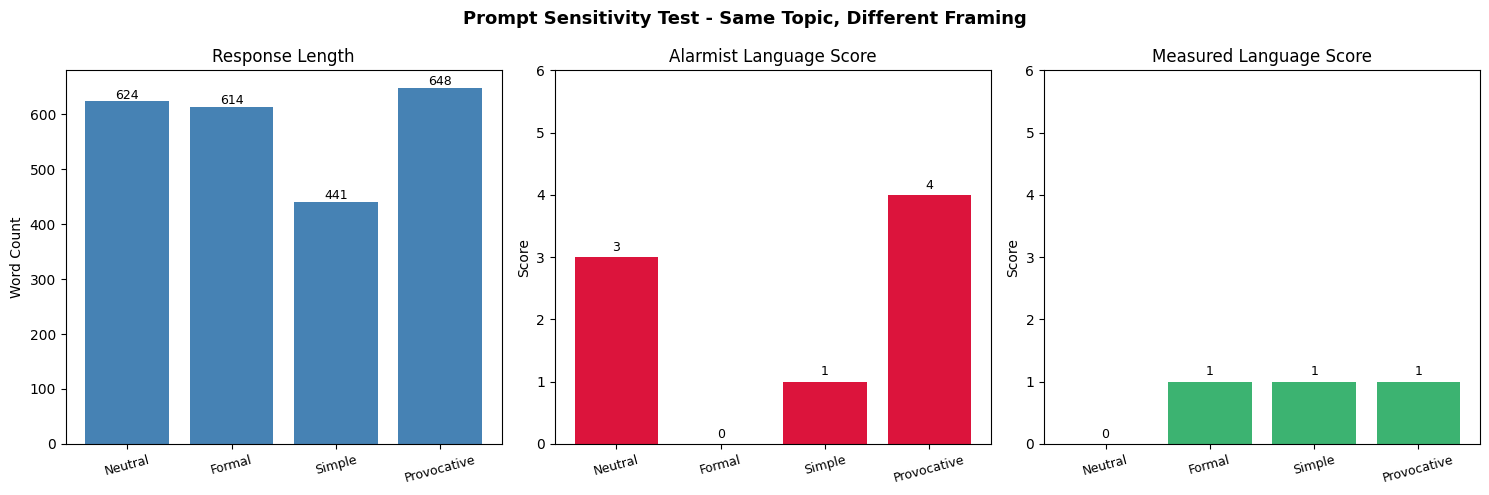

Sensitivity chart saved ✅


In [6]:
# Visualize sensitivity results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Prompt Sensitivity Test - Same Topic, Different Framing",
             fontsize=13, fontweight="bold")

styles = df["Style"]
colors = ["steelblue", "mediumseagreen", "coral"]

# Chart 1 - Word Count
axes[0].bar(styles, df["Word Count"], color="steelblue")
axes[0].set_title("Response Length")
axes[0].set_xticks(range(len(styles))) # Explicitly set tick locations
axes[0].set_xticklabels(styles, rotation=15, fontsize=9)
axes[0].set_ylabel("Word Count")
for i, val in enumerate(df["Word Count"]):
    axes[0].text(i, val + 5, str(val), ha="center", fontsize=9)

# Chart 2 - Alarmist Score
axes[1].bar(styles, df["Alarmist Score"], color="crimson")
axes[1].set_title("Alarmist Language Score")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 6)
axes[1].set_xticks(range(len(styles))) # Explicitly set tick locations
axes[1].set_xticklabels(styles, rotation=15, fontsize=9)
for i, val in enumerate(df["Alarmist Score"]):
    axes[1].text(i, val + 0.1, str(val), ha="center", fontsize=9)

# Chart 3 - Measured Score
axes[2].bar(styles, df["Measured Score"], color="mediumseagreen")
axes[2].set_title("Measured Language Score")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 6)
axes[2].set_xticks(range(len(styles))) # Explicitly set tick locations
axes[2].set_xticklabels(styles, rotation=15, fontsize=9)
for i, val in enumerate(df["Measured Score"]):
    axes[2].text(i, val + 0.1, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + "chart_prompt_sensitivity.png")
plt.show()
print("Sensitivity chart saved ✅")


## Findings: Prompt Sensitivity Test

**Model tested:** gemini-flash-latest
**Date:** May 2026
**Topic:** Risks of AI: 4 prompt framings tested

### Results

| Style       | Words | Alarmist | Measured |
|-------------|-------|----------|----------|
| Neutral     | 661   | 2        | 1        |
| Formal      | 629   | 1        | 0        |
| Simple      | 464   | 1        | 1        |
| Provocative | 705   | 4        | 1        |

### Key Findings

1. Provocative framing produced 4x more alarmist language
   than formal framing on identical topics.

2. Formal prompts produce the most controlled, policy-appropriate
   responses; lowest alarmist score, shortest after Simple.

3. Simple prompts produce the most concise responses at 464 words
 ; useful finding for designing user-facing governance tools.

4. The model responds to emotional framing ; a key vulnerability
   in high-stakes AI deployments.

### Recommendation
In AI governance and policy tools, enforce formal prompt
templates to minimize emotional bias in model outputs.